In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

# Paths
results_path = Path("../outputs/results")

# Load processed spatial data
adata = sc.read_h5ad(
    results_path / "AD_1_LS_processed.h5ad"
)

# Load image features
image_features = pd.read_csv(
    results_path / "AD_1_LS_image_features.csv",
    index_col=0
)

# Match spot order
common_spots = adata.obs_names.intersection(
    image_features.index
)

adata = adata[common_spots].copy()
image_features = image_features.loc[common_spots]

print("Dataset shape:", adata.shape)
print("Image feature shape:", image_features.shape)

Dataset shape: (188, 21587)
Image feature shape: (188, 7)


In [2]:
# Select target genes
target_genes = ["KRT14", "FLG"]

X = image_features.values

# Extract gene expression values
gene_indices = [
    adata.var_names.get_loc(gene)
    for gene in target_genes
]

Y = adata[:, gene_indices].X

if hasattr(Y, "toarray"):
    Y = Y.toarray()

Y = np.asarray(Y)

# Log-transform gene expression
Y = np.log1p(Y)

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

# Ridge regression baseline
model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)

model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

print("Training complete!")
print("Predictions shape:", Y_pred.shape)

Training complete!
Predictions shape: (38, 2)


In [3]:
# Evaluate each gene
for i, gene in enumerate(target_genes):

    mae = mean_absolute_error(
        Y_test[:, i],
        Y_pred[:, i]
    )

    r2 = r2_score(
        Y_test[:, i],
        Y_pred[:, i]
    )

    print(f"\n{gene}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")


KRT14
MAE: 0.6565
R²: 0.6904

FLG
MAE: 0.8009
R²: 0.3378


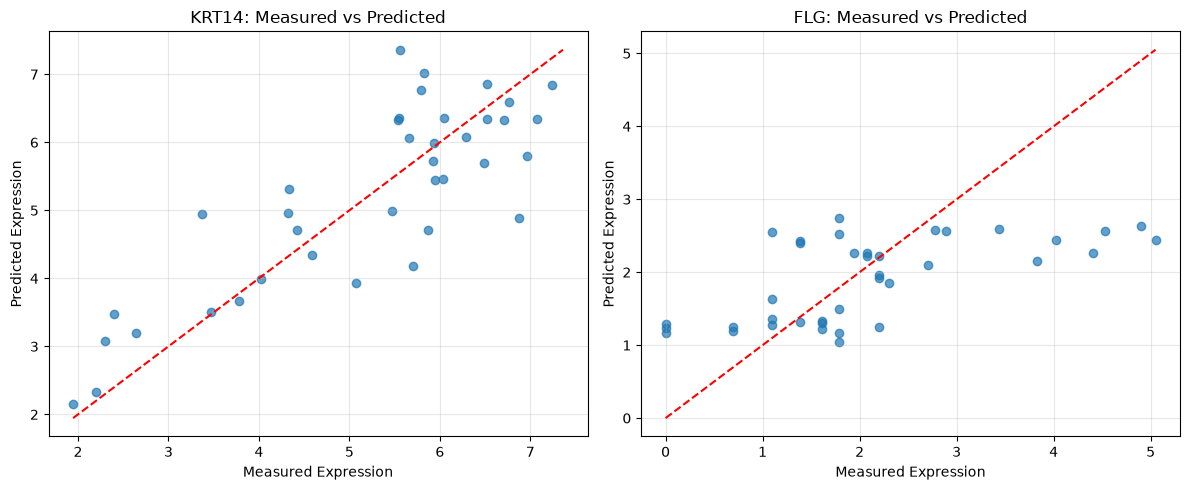

In [4]:
# Measured vs predicted expression

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, gene in enumerate(target_genes):

    axes[i].scatter(
        Y_test[:, i],
        Y_pred[:, i],
        alpha=0.7
    )

    min_value = min(
        Y_test[:, i].min(),
        Y_pred[:, i].min()
    )

    max_value = max(
        Y_test[:, i].max(),
        Y_pred[:, i].max()
    )

    axes[i].plot(
        [min_value, max_value],
        [min_value, max_value],
        "r--"
    )

    axes[i].set_xlabel("Measured Expression")
    axes[i].set_ylabel("Predicted Expression")
    axes[i].set_title(f"{gene}: Measured vs Predicted")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Save predictions and actual values

prediction_results = pd.DataFrame(
    Y_test,
    columns=[f"{gene}_measured" for gene in target_genes]
)

for i, gene in enumerate(target_genes):
    prediction_results[f"{gene}_predicted"] = Y_pred[:, i]

prediction_results.to_csv(
    results_path / "AD_1_LS_baseline_predictions.csv",
    index=False
)

print("Predictions saved successfully!")

Predictions saved successfully!


In [6]:
# Train final baseline model on all spots

final_model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)

final_model.fit(X, Y)

# Predict expression for all spots
Y_all_pred = final_model.predict(X)

print("Full dataset predictions:", Y_all_pred.shape)

Full dataset predictions: (188, 2)


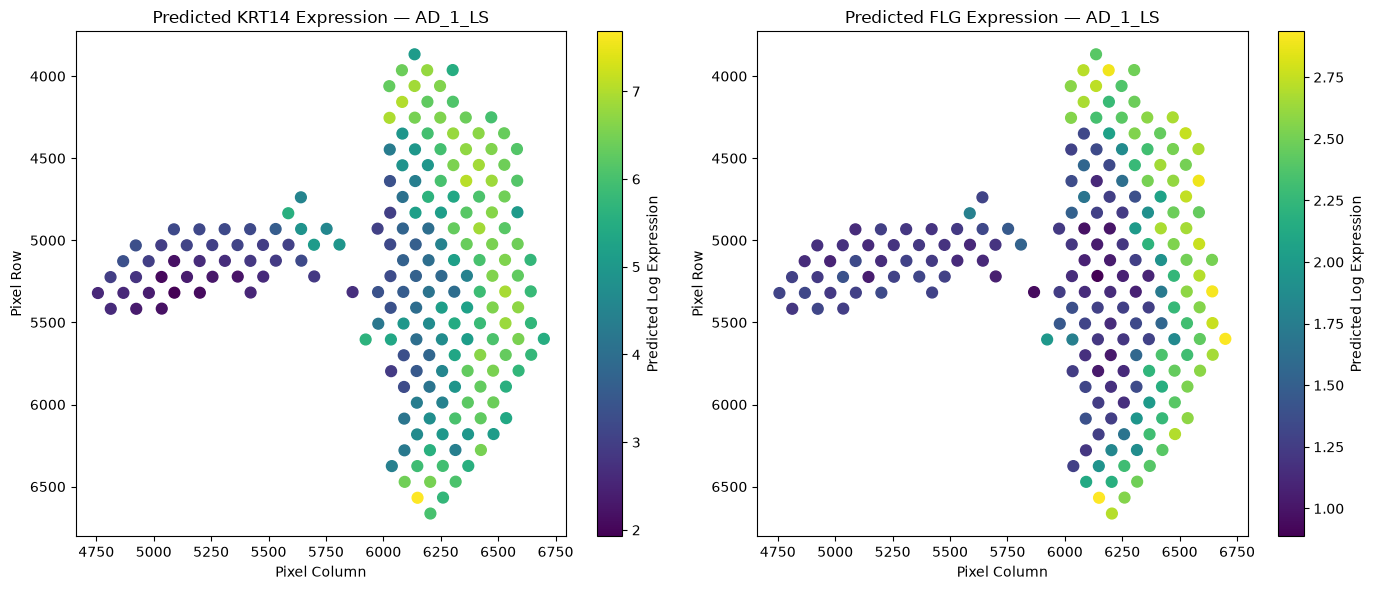

In [7]:
# Get spatial coordinates

x_coords = adata.obs["pixel_col"].values
y_coords = adata.obs["pixel_row"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, gene in enumerate(target_genes):

    scatter = axes[i].scatter(
        x_coords,
        y_coords,
        c=Y_all_pred[:, i],
        cmap="viridis",
        s=60
    )

    axes[i].invert_yaxis()
    axes[i].set_title(f"Predicted {gene} Expression — AD_1_LS")
    axes[i].set_xlabel("Pixel Column")
    axes[i].set_ylabel("Pixel Row")

    plt.colorbar(
        scatter,
        ax=axes[i],
        label="Predicted Log Expression"
    )

plt.tight_layout()
plt.show()

Figure saved to: ..\outputs\figures\AD_1_LS_predicted_expression.png


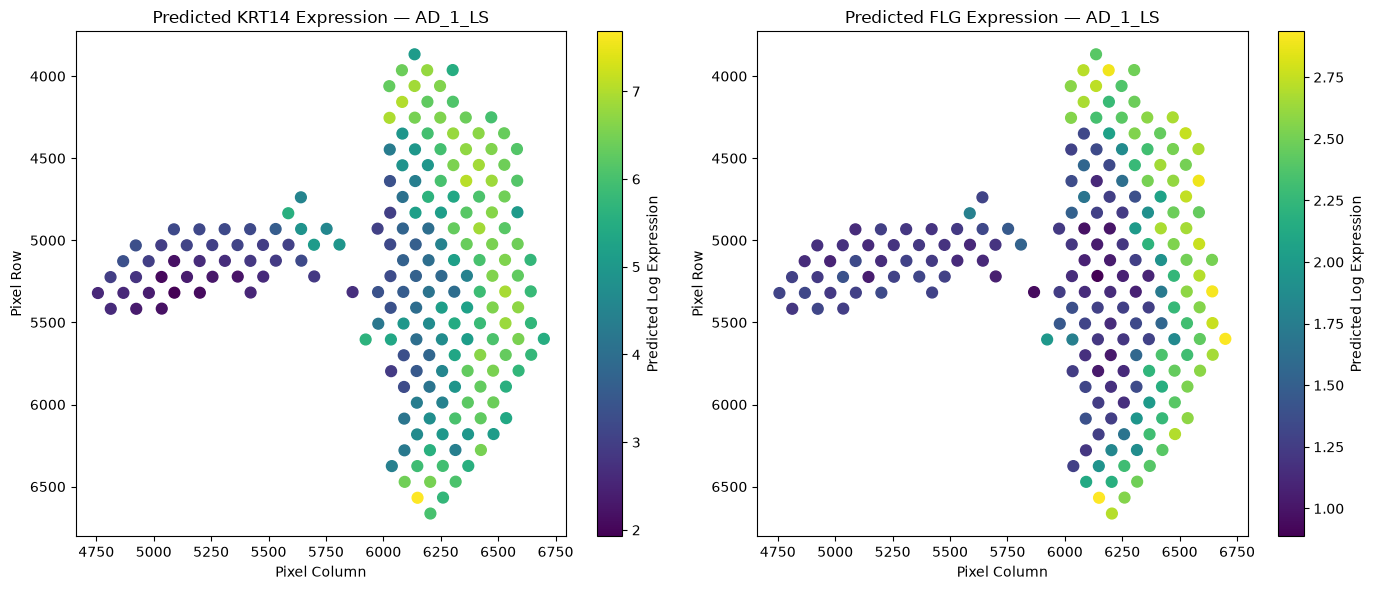

In [8]:
# Save predicted spatial expression maps

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, gene in enumerate(target_genes):

    scatter = axes[i].scatter(
        x_coords,
        y_coords,
        c=Y_all_pred[:, i],
        cmap="viridis",
        s=60
    )

    axes[i].invert_yaxis()
    axes[i].set_title(f"Predicted {gene} Expression — AD_1_LS")
    axes[i].set_xlabel("Pixel Column")
    axes[i].set_ylabel("Pixel Row")

    plt.colorbar(
        scatter,
        ax=axes[i],
        label="Predicted Log Expression"
    )

plt.tight_layout()

figure_path = Path("../outputs/figures/AD_1_LS_predicted_expression.png")
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

print(f"Figure saved to: {figure_path}")
plt.show()